# Model Training 

### Import Libraries and Packages

In [37]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

**Importing Data As CSV File**


In [38]:
df=pd.read_csv('Data/stud.csv')

# Show Top 5 Records


In [39]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Preparing X(feature columns) And Y(target Columns)

In [40]:
X =df.drop('math_score',axis=1)
y =df['math_score']

In [41]:
X.shape

(1000, 7)

In [42]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [43]:
print('Categories in Gender Column : ',end='')
print(df['gender'].unique())

print('Categories in race_ethinicity Column : ',end='')
print(df['race_ethnicity'].unique())

print('Categories in parental_level_of_education Column : ',end='')
print(df['parental_level_of_education'].unique())

print('Categories in lunch Column : ',end='')
print(df['lunch'].unique())

print('Categories in test_preparation_course Column : ',end='')
print(df['test_preparation_course'].unique())

Categories in Gender Column : <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in race_ethinicity Column : <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in parental_level_of_education Column : <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in lunch Column : <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test_preparation_course Column : <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [44]:
#Target column
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [45]:
#Creating Column Transformer with 3 types of transformers
cat_features= X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

numeric_transformer =StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor =ColumnTransformer(
    [
        ('OneHotEncoder',categorical_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features),
    ]
)

In [46]:
X=preprocessor.fit_transform(X)

In [47]:
X.shape

(1000, 19)

In [48]:
#Separating the data into train and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((800, 19), (800,), (200, 19), (200,))

### Creating an evaluate function to calculate metrics after modelling

In [49]:
def evaluate_model(true,pred):
    mae=mean_absolute_error(true,pred)
    mse=mean_squared_error(true,pred)
    rmse=np.sqrt(mean_squared_error(true,pred))
    r2_square = r2_score(true,pred)
    
    return mae,mse,rmse,r2_square

In [50]:
models={
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'KNN Regressor': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'XGB Regressor': XGBRegressor(),
    'CatBoost Regressor': CatBoostRegressor(verbose=False),
    'AdaBoost Regressor': AdaBoostRegressor()
}

model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    
    #Make Predictions
    y_train_pred=model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    #Evaluate the model
    mae_train,mse_train,rmse_train,r2_train=evaluate_model(y_train,y_train_pred)
    mae_test,mse_test,rmse_test,r2_test=evaluate_model(y_test,y_test_pred)
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    r2_list.append(r2_test)
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(rmse_train))
    print("- Mean Absolute Error: {:.4f}".format(mae_train))
    print("- R2 Score: {:.4f}".format(r2_train))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(rmse_test))
    print("- Mean Absolute Error: {:.4f}".format(mae_test))
    print("- R2 Score: {:.4f}".format(r2_test))
    
    print('='*35)
    print('\n')
    

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Ridge Regression
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


Lasso Regression
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


KNN Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7077
- Mean Absolute Error: 4.5167
- R2 Score: 0.8555
---------

### Results

In [52]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model','R2_Score']).sort_values(by=['R2_Score'],ascending=False)


,Model,R2_Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
7,CatBoost Regressor,0.851632
8,AdaBoost Regressor,0.851383
5,Random Forest Regressor,0.848459
6,XGB Regressor,0.827797
2,Lasso Regression,0.825320
3,KNN Regressor,0.783813
4,Decision Tree Regressor,0.745355


### Linear Regression 
* Linear Regression is simple and easy to implement ,r2_score is almost equal to ridge regression hence we are going with Linear Regression

In [58]:
lin_model = LinearRegression()
lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score = r2_score(y_test,y_pred)
print(f'Accuracy of Linear regression Model is : {score *100:.2f}%')

Accuracy of Linear regression Model is : 88.04%


### Plot between y_test and y_pred 

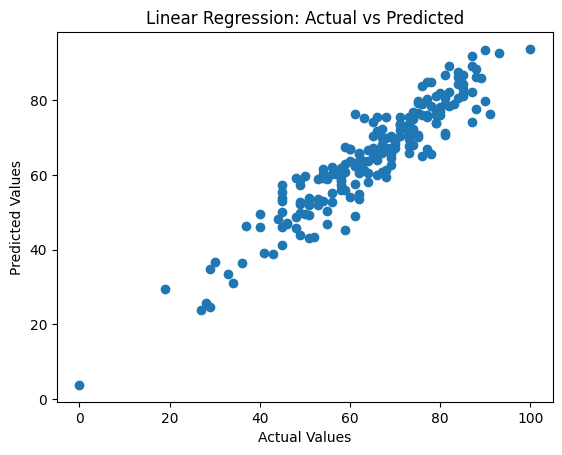

In [59]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

<Axes: xlabel='math_score'>

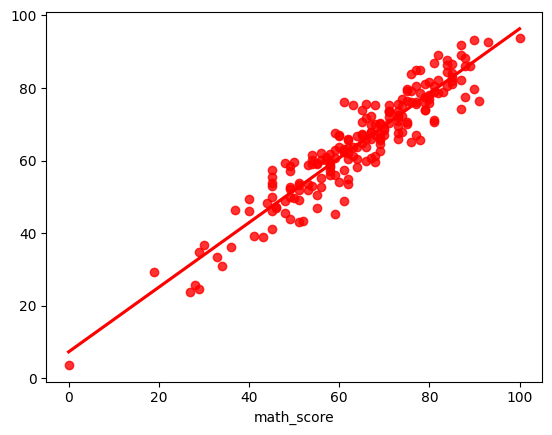

In [60]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

### Difference between predicted and Actual Values

In [61]:
pred_df = pd.DataFrame({'Actual':y_test,'Predicted':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
